In [2]:

import pandas as pd
from sklearn.linear_model import LogisticRegression
import matplotlib.pyplot as plt
import seaborn as sns

# Cargar archivos
train_data = pd.read_csv("../csv/train.csv")
test_data = pd.read_csv("../csv/test.csv")


### Crear PriceCategory

In [3]:

# Crear PriceCategory por percentiles
q1 = train_data["SalePrice"].quantile(0.33)
q2 = train_data["SalePrice"].quantile(0.66)

train_data["PriceCategory"] = pd.cut(train_data["SalePrice"],
    bins=[train_data["SalePrice"].min(), q1, q2, train_data["SalePrice"].max()],
    labels=["Economica", "Media", "Cara"], include_lowest=True)

# Variable binaria: EsCara
train_data["EsCara"] = (train_data["PriceCategory"] == "Cara").astype(int)


### Limpiar test

In [4]:

cols_to_drop = [
    "Id", "Alley", "PoolQC", "Fence", "MiscFeature", "Utilities", "FireplaceQu",
    "GarageYrBlt", "GarageQual", "GarageCond", "Neighborhood", "Condition1",
    "Condition2", "RoofMatl", "Exterior1st", "Exterior2nd", "SalePrice", "PriceCategory"
]

train_data.drop(columns=cols_to_drop, inplace=True, errors='ignore')
test_data.drop(columns=cols_to_drop[:-2], inplace=True, errors='ignore')  # test no tiene SalePrice ni PriceCategory


In [5]:

columns_to_encode = [
    'MSZoning', 'Street', 'LotShape', 'LandContour', 'LotConfig', 'LandSlope',
    'BldgType', 'MasVnrType', 'ExterQual', 'ExterCond', 'Foundation', 'BsmtQual',
    'BsmtCond', 'BsmtExposure', 'BsmtFinType1', 'BsmtFinType2', 'Heating', 'HeatingQC',
    'CentralAir', 'Electrical', 'KitchenQual', 'Functional', 'GarageType', 'GarageFinish',
    'PavedDrive', 'SaleType', 'SaleCondition'
]

train_data = pd.get_dummies(train_data, columns=columns_to_encode, drop_first=True)
test_data = pd.get_dummies(test_data, columns=columns_to_encode, drop_first=True)

# Alinear columnas
test_data = test_data.reindex(columns=train_data.drop(columns=["EsCara"]).columns, fill_value=0)


In [6]:

train_data.fillna(train_data.median(numeric_only=True), inplace=True)
test_data.fillna(test_data.median(numeric_only=True), inplace=True)

for col in train_data.columns:
    if train_data[col].dtype != 'object':
        train_data[col] = train_data[col].astype(int)

for col in test_data.columns:
    if test_data[col].dtype != 'object':
        test_data[col] = test_data[col].astype(int)


## Variables de test 

In [7]:
# Eliminar columnas categóricas que no se codificaron
for df in [train_data, test_data]:
    obj_cols = df.select_dtypes(include=["object"]).columns
    df.drop(columns=obj_cols, inplace=True)

# Ahora sí: separar X e y
X_train = train_data.drop(columns=["EsCara"])
y_train = train_data["EsCara"]

# Entrenar y predecir
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

y_pred = model.predict(test_data)

print("Predicciones en test.csv realizadas.")
print("Primeras 10 predicciones:", y_pred[:10])


Predicciones en test.csv realizadas.
Primeras 10 predicciones: [0 0 0 0 0 0 0 0 0 0]


c:\Users\thiag\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


# Resultados

C:\Users\thiag\AppData\Local\Temp\ipykernel_36964\4067841870.py:5: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  test_data["PredEsCara"] = y_pred
C:\Users\thiag\AppData\Local\Temp\ipykernel_36964\4067841870.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=conteo.values, palette="Set2")


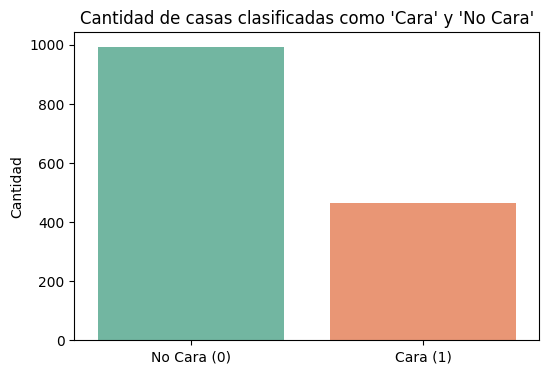

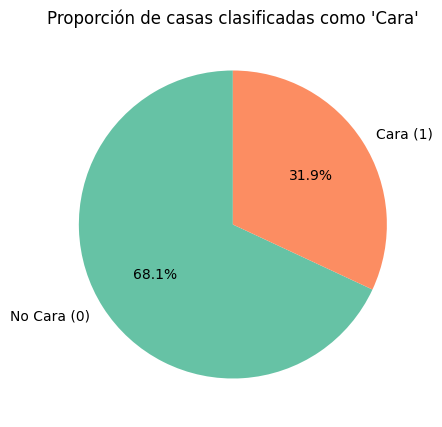

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns

# Agregar las predicciones al test
test_data["PredEsCara"] = y_pred

# Conteo de clases
conteo = test_data["PredEsCara"].value_counts().sort_index()
labels = ["No Cara (0)", "Cara (1)"]

# Gráfico de barras
plt.figure(figsize=(6, 4))
sns.barplot(x=labels, y=conteo.values, palette="Set2")
plt.title("Cantidad de casas clasificadas como 'Cara' y 'No Cara'")
plt.ylabel("Cantidad")
plt.show()

# Gráfico de pastel
plt.figure(figsize=(5, 5))
plt.pie(conteo.values, labels=labels, autopct='%1.1f%%', startangle=90, colors=["#66c2a5", "#fc8d62"])
plt.title("Proporción de casas clasificadas como 'Cara'")
plt.show()
